In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torch.nn.functional as F
import psutil
import logging

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#torch.cuda.empty_cache()

In [ ]:
logging.basicConfig(
    filename="memory_log.txt",
    level=logging.INFO,
    format="%(asctime)s %(message)s"
)

def log_memory(tag=""):
    process = psutil.Process(os.getpid())
    cpu_mem = process.memory_info().rss / 1024**3

    if torch.cuda.is_available():
        gpu_alloc = torch.cuda.memory_allocated() / 1024**3
        gpu_reserved = torch.cuda.memory_reserved() / 1024**3
    else:
        gpu_alloc = gpu_reserved = 0

    logging.info(
        f"{tag} | CPU {cpu_mem:.3f} GB | GPU alloc {gpu_alloc:.3f} GB | GPU reserved {gpu_reserved:.3f} GB"
    )

In [2]:
if not os.path.exists('tiny_nerf_data.npz'):
    !wget http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz

--2026-03-17 09:26:56--  http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz
Resolving cseweb.ucsd.edu (cseweb.ucsd.edu)... 132.239.8.30
Connecting to cseweb.ucsd.edu (cseweb.ucsd.edu)|132.239.8.30|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cseweb.ucsd.edu//~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz [following]
--2026-03-17 09:26:56--  https://cseweb.ucsd.edu//~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz
Connecting to cseweb.ucsd.edu (cseweb.ucsd.edu)|132.239.8.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12727482 (12M)
Saving to: ‘tiny_nerf_data.npz’

tiny_nerf_data.npz  100%[===================>]  12.14M  29.2MB/s    in 0.4s    

2026-03-17 09:26:56 (29.2 MB/s) - ‘tiny_nerf_data.npz’ saved [12727482/12727482]



(106, 100, 100, 3) (106, 4, 4) 138.88887889922103


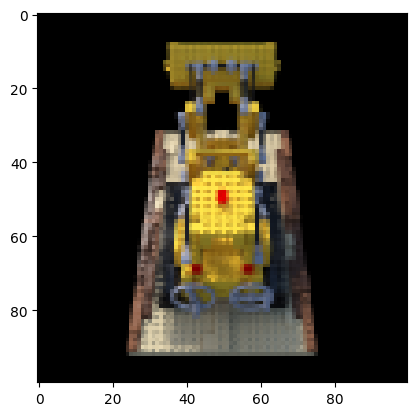

In [3]:
data = np.load('tiny_nerf_data.npz')
images = data['images']
poses = data['poses']
focal = data['focal']
H, W = images.shape[1:3]
print(images.shape, poses.shape, focal)

testimg, testpose = images[102], poses[102]
images = images[:100,...,:3]
poses = poses[:100]

images = torch.tensor(images, dtype=torch.float32)
poses = torch.tensor(poses, dtype=torch.float32)
testimg = torch.tensor(testimg, dtype=torch.float32)
testpose = torch.tensor(testpose, dtype=torch.float32)
focal = torch.tensor(focal, dtype=torch.float32)

plt.imshow(testimg)
plt.show()

In [4]:
def posenc(x, L_embed):
    rets = [x]
    for i in range(L_embed):
        for fn in [torch.sin, torch.cos]:
            rets.append(fn(2.**i * x))
    return torch.cat(rets, dim=-1)

L_embed_pts = 10
L_embed_views = 4

In [5]:
class NeRF(nn.Module):
    def __init__(self, D=8, W=256, L_pts=10, L_views=4):
        super().__init__()
        self.L_pts = L_pts
        self.L_views = L_views

        input_dim_pts = 3 + 3 * 2 * L_pts
        input_dim_views = 3 + 3 * 2 * L_views

        # Couches pour traiter la position (x, y, z)
        self.pts_layers = nn.ModuleList([nn.Linear(input_dim_pts, W)])
        for i in range(1,D):
            if i == 4:
                self.pts_layers.append(nn.Linear(W + input_dim_pts, W))
            else:
                self.pts_layers.append(nn.Linear(W, W))

        # Sortie de la densité
        self.sigma_layer = nn.Linear(W, 1)

        # Branche pour la couleur
        self.feature_layer = nn.Linear(W, W)
        self.views_layer = nn.Linear(W + input_dim_views, W // 2)
        self.rgb_layer = nn.Linear(W // 2, 3)

    def forward(self, pts_enc, views_enc):
        # Position
        h = pts_enc
        for i, layer in enumerate(self.pts_layers):
            if i == 4:
                h = torch.cat([pts_enc, h], dim=-1)
            h = F.relu(layer(h))
        # On récupère la densité
        sigma = self.sigma_layer(h)
        # On ajoute la direction de vue pour le RGB
        feature = self.feature_layer(h)
        h = torch.cat([feature, views_enc], dim=-1)
        h = F.relu(self.views_layer(h))
        rgb = torch.sigmoid(self.rgb_layer(h))

        return torch.cat([rgb, sigma], dim=-1)

In [6]:
def get_rays(H, W, focal, c2w):
    i, j = torch.meshgrid(torch.arange(W, dtype=torch.float32, device=c2w.device), torch.arange(H, dtype=torch.float32, device=c2w.device), indexing='xy')
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], -1)
    rays_d = torch.sum(dirs[..., np.newaxis, :] * c2w[:3,:3], -1)
    rays_o = c2w[:3,-1].expand(rays_d.shape)
    return rays_o, rays_d


def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, rand=False):

    def batchify(fn, chunk=1024*32):
        return lambda inputs: torch.cat([fn(inputs[0][i:i+chunk], inputs[1][i:i+chunk]) for i in range(0, inputs[0].shape[0], chunk)], dim=0)
    # Compute 3D query points
    z_vals = torch.linspace(near, far, N_samples, device=rays_o.device)
    if rand:
        z_vals = z_vals + torch.rand(list(rays_o.shape[:-1]) + [N_samples], device=rays_o.device) * (far - near) / N_samples
    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]

    # View management
    norm = torch.norm(rays_d, dim=-1, keepdim=True)
    viewdirs = rays_d / (norm + 1e-10) # Vecteur unitaire (N_rays, 3)
    viewdirs = viewdirs[..., None, :].expand(pts.shape) # (N_rays, N_samples, 3)

    # Data rework for network
    pts_flat = pts.reshape(-1, 3)
    views_flat = viewdirs.reshape(-1, 3)

    pts_enc = posenc(pts_flat, L_embed_pts)
    views_enc = posenc(views_flat, L_embed_views)

    # Run network
    raw = batchify(network_fn)([pts_enc, views_enc])
    raw = raw.reshape(list(pts.shape[:-1]) + [4])

    # Volume rendering
    #sigma_logits = raw[..., 3]
    # if rand: # On n'ajoute du bruit que pendant l'entraînement
    #     noise = torch.randn_like(sigma_logits) * 1.0 # 1.0 est l'écart-type standard
    #     sigma_a = F.softplus(sigma_logits + noise)
    # else:
    #     sigma_a = F.softplus(sigma_logits)
    #sigma_a = F.softplus(sigma_logits)

    sigma_a = F.relu(raw[..., 3])
    rgb = raw[..., :3] # Plus de sigmoid

    dists = torch.cat([z_vals[..., 1:] - z_vals[..., :-1], torch.full_like(z_vals[..., :1], 1e10)], dim=-1)
    alpha = 1. - torch.exp(-sigma_a * dists)
    weights = alpha * torch.cumprod(torch.cat([torch.ones_like(alpha[..., :1]), 1. - alpha + 1e-10], dim=-1), dim=-1)[..., :-1]

    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    depth_map = torch.sum(weights * z_vals, dim=-1)
    acc_map = torch.sum(weights, dim=-1)

    return rgb_map, depth_map, acc_map

0 0.04651885986328125 secs per iter
Iteration 0: tensor(0.4750, device='cuda:0')
Test MSE: 0.171234


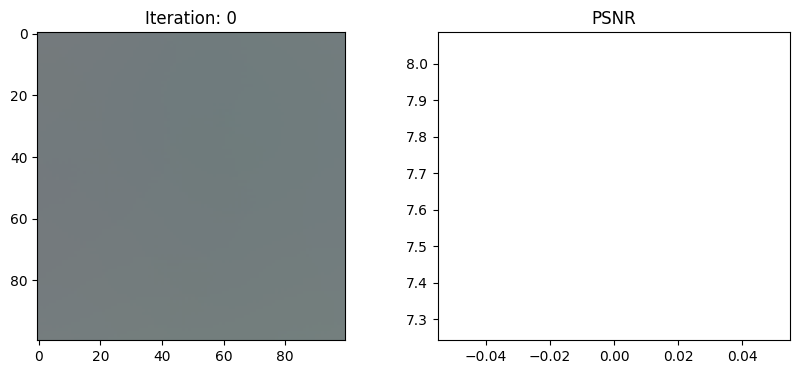

25 0.1103667163848877 secs per iter
Iteration 25: tensor(0.0893, device='cuda:0')
Test MSE: 0.049452


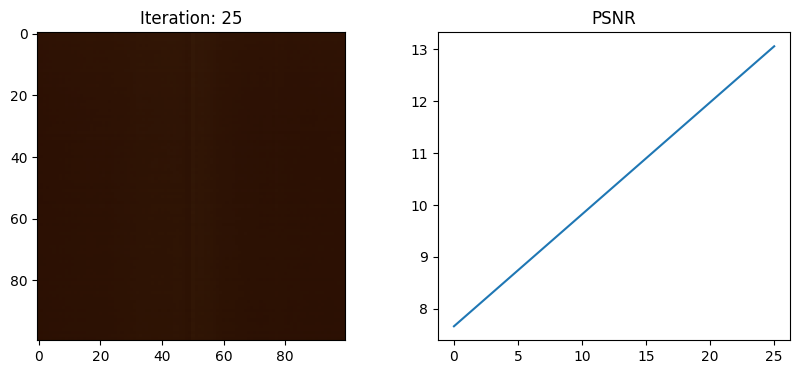

50 0.10120414733886719 secs per iter
Iteration 50: tensor(0.1453, device='cuda:0')
Test MSE: 0.044104


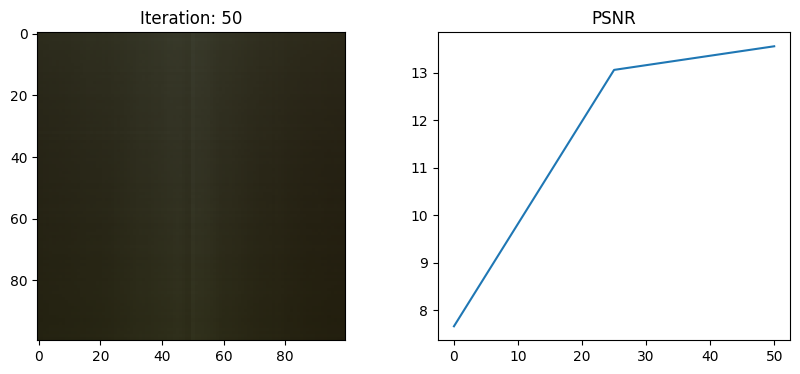

75 0.10209093093872071 secs per iter
Iteration 75: tensor(0.1275, device='cuda:0')
Test MSE: 0.039155


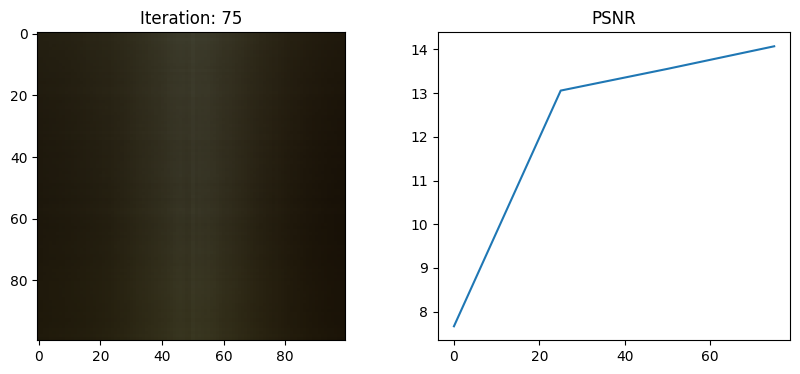

100 0.10151352882385253 secs per iter
Iteration 100: tensor(0.0770, device='cuda:0')
Test MSE: 0.040945


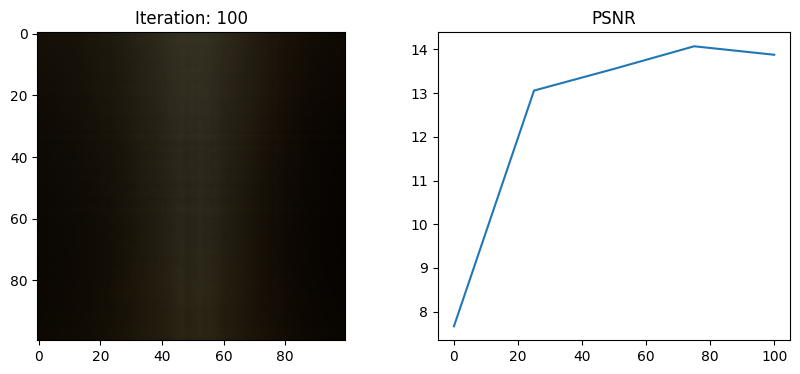

125 0.10615840911865235 secs per iter
Iteration 125: tensor(0.1620, device='cuda:0')
Test MSE: 0.032581


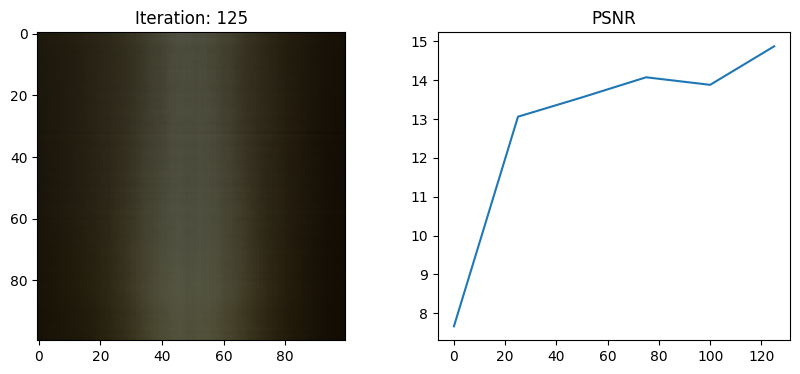

150 0.10375595092773438 secs per iter
Iteration 150: tensor(0.1362, device='cuda:0')
Test MSE: 0.026053


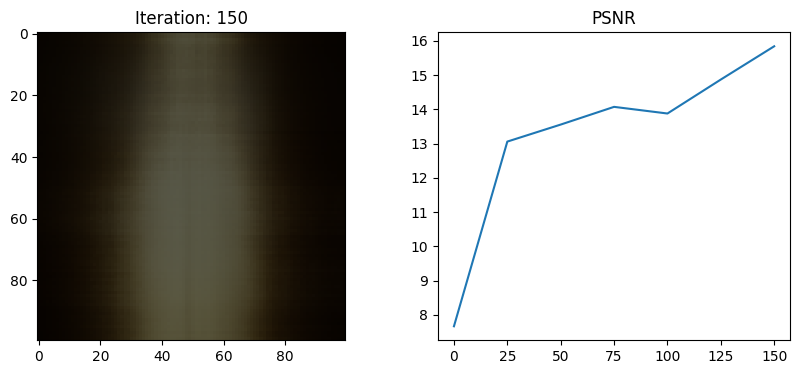

175 0.10999316215515137 secs per iter
Iteration 175: tensor(0.1036, device='cuda:0')
Test MSE: 0.023473


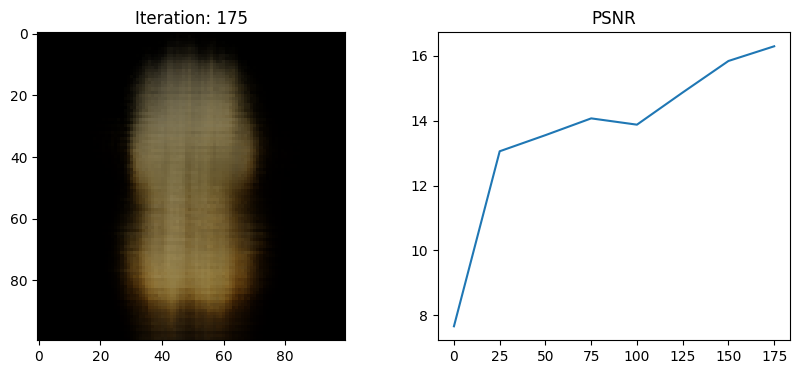

200 0.1018581485748291 secs per iter
Iteration 200: tensor(0.1090, device='cuda:0')
Test MSE: 0.021139


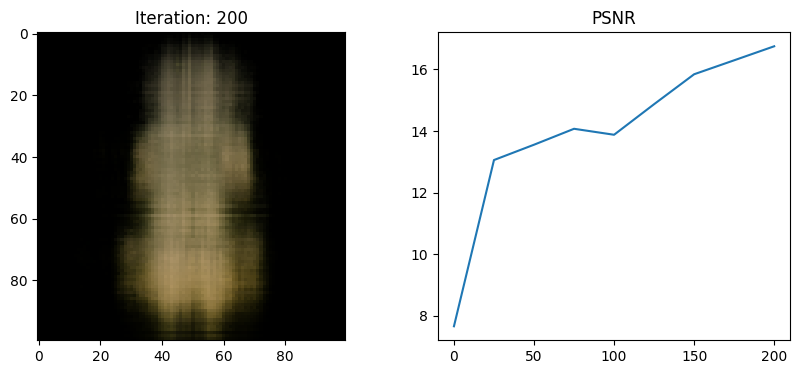

225 0.11126294136047363 secs per iter
Iteration 225: tensor(0.1176, device='cuda:0')
Test MSE: 0.018163


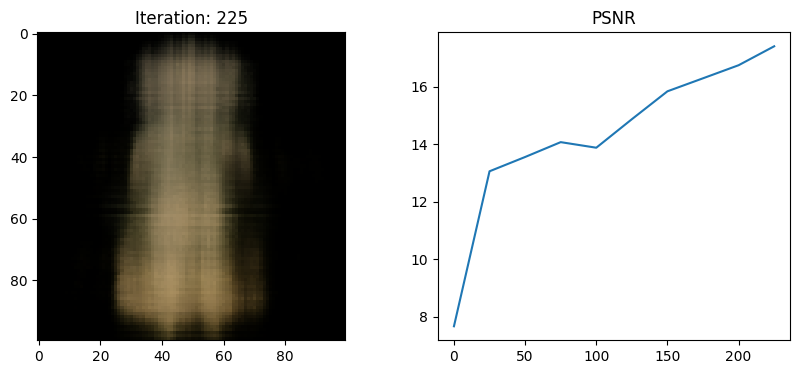

250 0.10181000709533691 secs per iter
Iteration 250: tensor(0.1330, device='cuda:0')
Test MSE: 0.015967


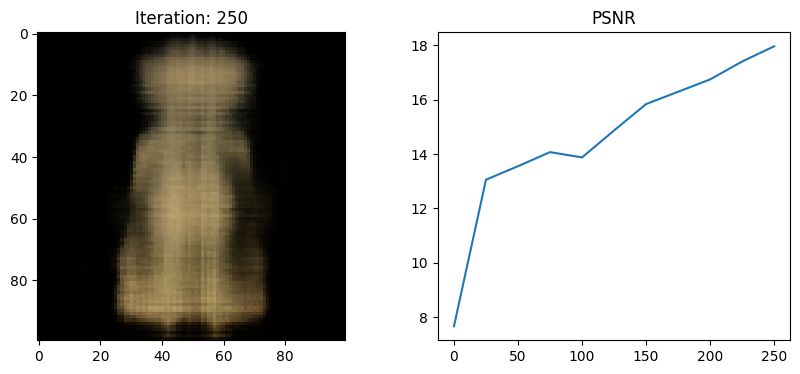

275 0.10132037162780762 secs per iter
Iteration 275: tensor(0.1046, device='cuda:0')
Test MSE: 0.014690


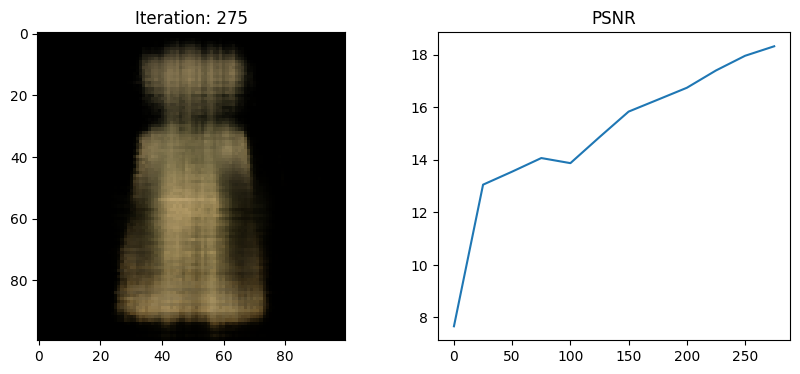

300 0.10197481155395507 secs per iter
Iteration 300: tensor(0.1074, device='cuda:0')
Test MSE: 0.014597


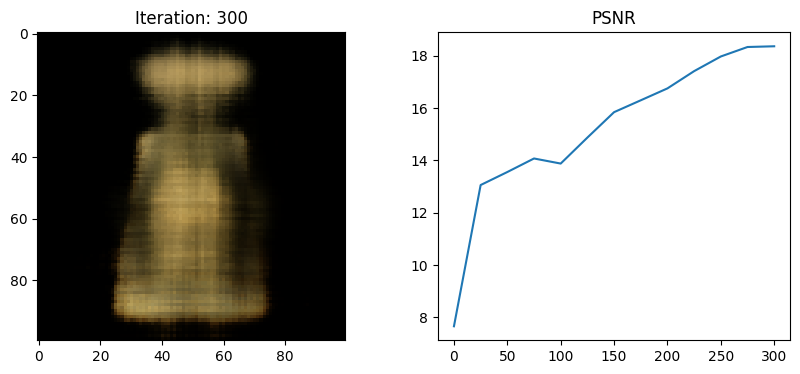

325 0.11509381294250488 secs per iter
Iteration 325: tensor(0.1208, device='cuda:0')
Test MSE: 0.011634


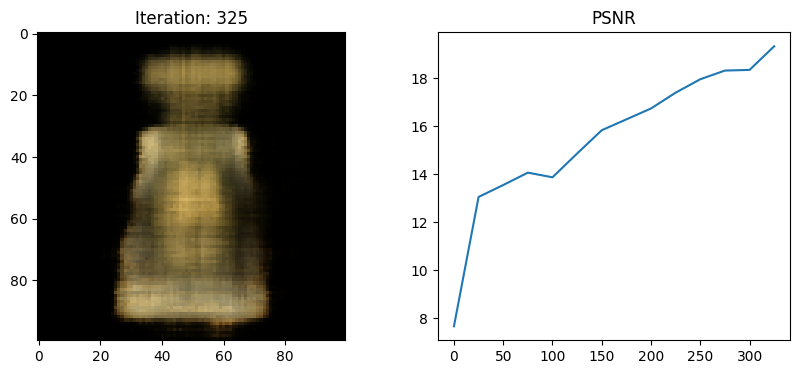

350 0.1103586196899414 secs per iter
Iteration 350: tensor(0.1330, device='cuda:0')
Test MSE: 0.012846


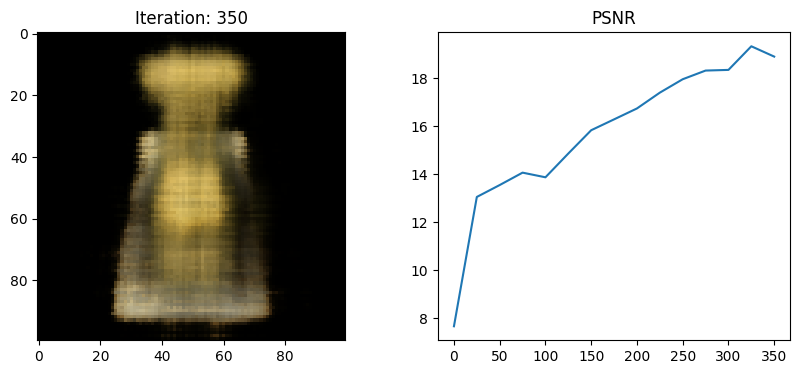

375 0.10406533241271973 secs per iter
Iteration 375: tensor(0.1512, device='cuda:0')
Test MSE: 0.012656


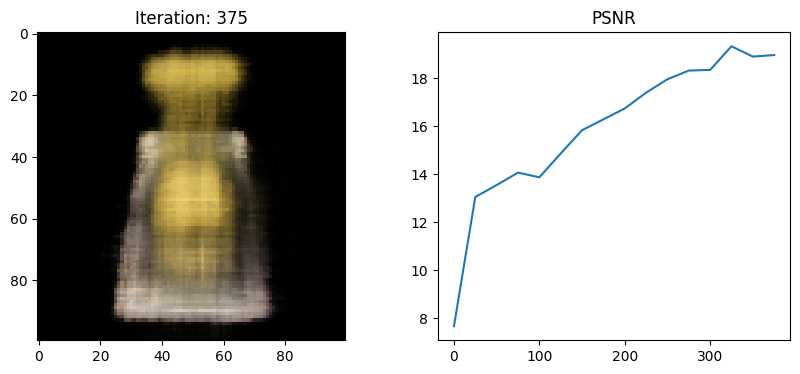

400 0.10271145820617676 secs per iter
Iteration 400: tensor(0.1249, device='cuda:0')
Test MSE: 0.010491


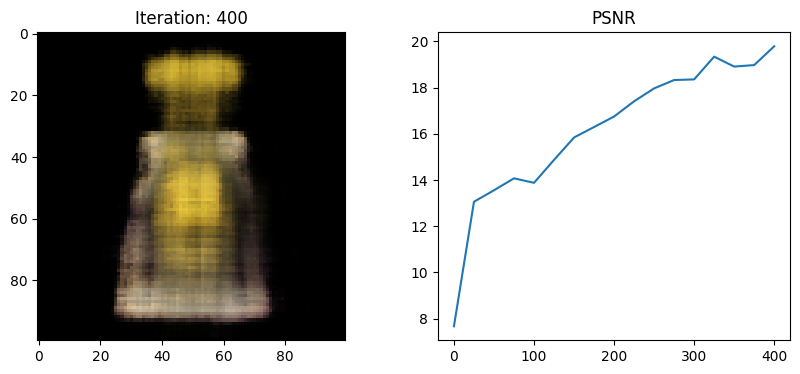

425 0.10274992942810059 secs per iter
Iteration 425: tensor(0.1312, device='cuda:0')
Test MSE: 0.009639


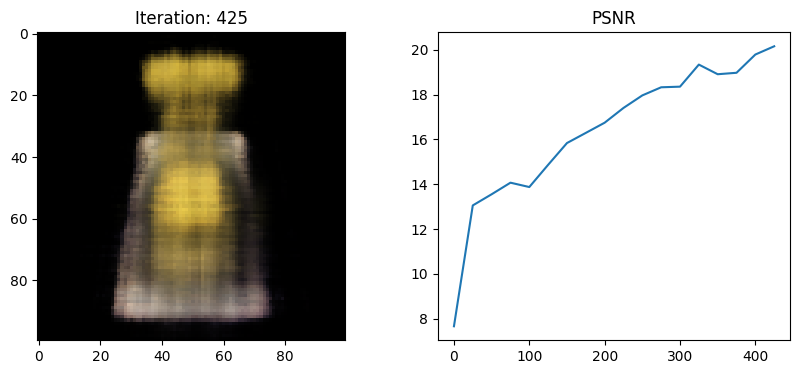

450 0.10439031600952148 secs per iter
Iteration 450: tensor(0.1412, device='cuda:0')
Test MSE: 0.009994


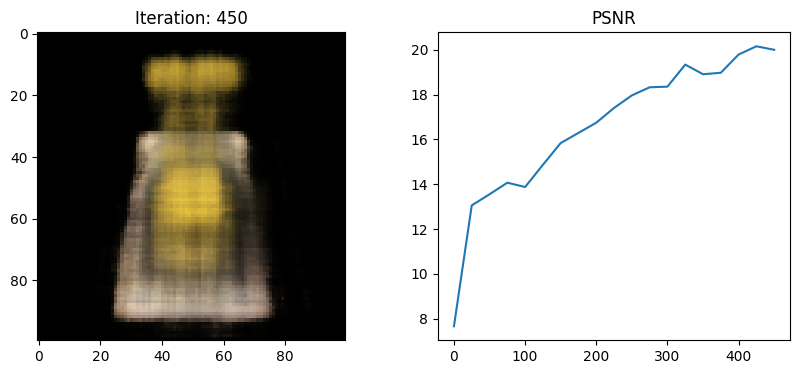

KeyboardInterrupt: 

In [7]:
L_embed_pts = 10
L_embed_views = 4
model = NeRF().to(device)
#with torch.no_grad():
    # On initialise le biais de la couche sigma pour démarrer avec peu de densité
#    model.sigma_layer.bias.fill_(-1.0)
optimizer = optim.Adam(model.parameters(), lr=5e-4)
model.to(device)
focal = focal.to(device)

N_samples = 64
N_iters = 1000
psnrs = []
iternums = []
i_plot = 25

N_rand = 1024
#gamma = 0.1**(5/N_iters)
#scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)


import time
t = time.time()
for i in range(N_iters + 1):

    # log_memory("iter_start")

    img_i = np.random.randint(images.shape[0])
    target = images[img_i].to(device)
    pose = poses[img_i].to(device)
    rays_o, rays_d = get_rays(H, W, focal, pose)


    coords = torch.stack(torch.meshgrid(torch.arange(H, device=device),torch.arange(W, device=device), indexing='ij'), -1).reshape(-1, 2)


    select_inds   = np.random.choice(coords.shape[0], size=[N_rand], replace=False)
    select_coords = coords[select_inds].long()
    rays_o_batch = rays_o[select_coords[:, 0], select_coords[:, 1]]
    rays_d_batch = rays_d[select_coords[:, 0], select_coords[:, 1]]
    target_s = target[select_coords[:, 0], select_coords[:, 1]]


    rgb_pred, _, _ = render_rays(model, rays_o_batch, rays_d_batch, near=2., far=6., N_samples=N_samples, rand=True)
    loss = torch.mean((rgb_pred - target_s) ** 2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    #scheduler.step()

    # log_memory("after_train")


    if i%i_plot==0:
        with torch.no_grad():
            print(i, (time.time() - t) / i_plot, 'secs per iter')
            t = time.time()

            rays_o_test, rays_d_test = get_rays(H, W, focal, testpose.to(device))
            rgb, depth, acc = render_rays(model, rays_o_test, rays_d_test, near=2., far=6., N_samples=N_samples)
            loss_test = torch.mean((rgb - testimg.to(device)) ** 2)
            psnr = -10 * torch.log10(loss_test).item()
            psnrs.append(psnr)
            iternums.append(i)

            print(f"Iteration {i}:", torch.mean(rgb))
            print(f"Test MSE: {loss_test.item():.6f}")

            plt.figure(figsize=(10,4))
            plt.subplot(121)
            plt.imshow(rgb.detach().cpu().numpy())
            plt.title(f'Iteration: {i}')
            plt.subplot(122)
            plt.plot(iternums, psnrs)
            plt.title('PSNR')
            plt.show()

   # torch.cuda.empty_cache()

In [ ]:
%matplotlib inline
from ipywidgets import interactive, widgets


trans_t = lambda t : torch.tensor([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,1,t],
    [0,0,0,1],
], dtype=torch.float32)

rot_phi = lambda phi : torch.tensor([
    [1,0,0,0],
    [0,torch.cos(torch.tensor(phi)),-torch.sin(torch.tensor(phi)),0],
    [0,torch.sin(torch.tensor(phi)), torch.cos(torch.tensor(phi)),0],
    [0,0,0,1],
], dtype=torch.float32)

rot_theta = lambda th : torch.tensor([
    [torch.cos(torch.tensor(th)),0,-torch.sin(torch.tensor(th)),0],
    [0,1,0,0],
    [torch.sin(torch.tensor(th)),0, torch.cos(torch.tensor(th)),0],
    [0,0,0,1],
], dtype=torch.float32)


def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(phi/180.*np.pi) @ c2w
    c2w = rot_theta(theta/180.*np.pi) @ c2w
    # Convert the numpy array to a torch tensor before multiplication
    c2w = torch.tensor([[-1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]], dtype=torch.float32) @ c2w
    return c2w


def f(**kwargs):
    c2w = pose_spherical(**kwargs)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
    img = np.clip(rgb,0,1)

    plt.figure(2, figsize=(20,6))
    plt.imshow(img)
    plt.show()


sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [4., 3., 5.]],
]

interactive_plot = interactive(f, **{s[0] : sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot

interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

In [ ]:
frames = []
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = pose_spherical(th, -30., 4.)
    c2w = c2w.to(device) # Move c2w to the correct device
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)
    frames.append((255*np.clip(rgb.detach().cpu().numpy(),0,1)).astype(np.uint8)) # Detach and move to CPU before numpy conversion

import imageio
f = 'video.mp4'
imageio.mimwrite(f, frames, fps=30, quality=7)

 62%|██████▏   | 74/120 [00:29<00:18,  2.53it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 25.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.34 GiB is allocated by PyTorch, and 63.52 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)